# Teil 1 - Use Case Analyse

## 1. Datensatz-Beschreibung: Was wurde erfasst, von wem und warum?

Laut der offiziellen Beschreibung auf Kaggle ("E-Commerce Shipping Data", [kaggle.com/datasets/prachi13/customer-analytics](https://www.kaggle.com/datasets/prachi13/customer-analytics)) stammt der Datensatz von einem **internationalen E-Commerce-Unternehmen, das Elektronikprodukte verkauft**. Das Unternehmen wollte anhand seiner Kundendatenbank wichtige Erkenntnisse ("key insights") über sein Geschäft gewinnen, insbesondere im Zusammenhang mit der Lieferzuverlässigkeit.

Der Datensatz enthält **10.999 Bestelldatensätze** (Train.csv, 12 Spalten). Erfasst wurden pro Bestellung u. a.:

- **Logistik-Merkmale**: Lagerblock (`Warehouse_block`: A–F), Versandart (`Mode_of_Shipment`: Flight, Ship, Road), Produktgewicht (`Weight_in_gms`)
- **Kundenbezogene Merkmale**: Anzahl Anrufe beim Kundenservice zur Sendungsanfrage (`Customer_care_calls`), Kundenbewertung 1–5 (`Customer_rating`), Geschlecht (`Gender`), Anzahl früherer Käufe (`Prior_purchases`)
- **Produkt-/Bestellmerkmale**: Produktpreis in USD (`Cost_of_the_Product`), Produktwichtigkeit (`Product_importance`: low/medium/high), gewährter Rabatt (`Discount_offered`)
- **Zielgröße**: ob die Lieferung pünktlich ankam (`Reached.on.Time_Y.N`, 1 = nicht pünktlich, 0 = pünktlich)

Erfasst wurde der Datensatz vom **operativen/logistischen System des Händlers** (Auftragsverwaltung, Versand- und CRM-Systeme), das bei jeder Bestellung automatisch Versand-, Produkt- und Kundendaten mitschreibt. Der Zweck der Erfassung ist die **Nachverfolgung der Lieferzuverlässigkeit**: Das Unternehmen möchte verstehen, welche Faktoren (Versandart, Gewicht, Rabatt, Kundenverhalten etc.) mit verspäteten Lieferungen zusammenhängen, um daraus Optimierungspotenzial für die Lieferkette abzuleiten.

## 2. Business-Fragestellung

**Kann das Unternehmen anhand von Bestell-, Versand- und Kundenmerkmalen einer neuen Sendung frühzeitig erkennen, ob diese sich verspäten wird, um durch gezieltes Gegensteuern (z. B. Versandart wechseln, Kunden proaktiv informieren) Reklamationen zu vermeiden und die Kundenzufriedenheit zu erhöhen?**

## 3. Art des Problems

Es handelt sich um ein **Klassifikationsproblem**, genauer eine **binäre Klassifikation**.

**Begründung:** Die Zielvariable `Reached.on.Time_Y.N` nimmt nur zwei diskrete Werte an (0 = pünktlich, 1 = nicht pünktlich). Es soll also keine kontinuierliche Zahl vorhergesagt werden, sondern eine Bestellung einer von zwei Klassen zugeordnet werden. 

## 4. Mehrwert

Ein trainiertes Modell könnte einem Unternehmen folgenden Nutzen bringen:

- **Proaktives Risikomanagement**: Bestellungen mit hohem Verspätungsrisiko können frühzeitig identifiziert werden, sodass der Kunde informiert oder die Sendung priorisiert bearbeitet werden kann.
- **Optimierung der Lieferkette**: Erkenntnisse darüber, welche Faktoren (z. B. Versandart, Gewicht, Lagerblock) Verspätungen begünstigen, helfen bei der Prozessverbesserung (z. B. Wechsel der Versandart für kritische Produkte).
- **Realistischere Lieferzeitangaben**: Realistischere Lieferzeitangaben erhöhen die Kundenzufriedenheit und senken Support-Anfragen (die Anzahl der `Customer_care_calls` zeigt, dass Lieferunsicherheit bereits heute Supportaufwand verursacht).
- **Kosteneinsparung**: Weniger Reklamationen, Rückerstattungen und Eilzustellungen durch gezieltes Gegensteuern bei Risikobestellungen.
- **Datengetriebene Entscheidungen**: Das Modell liefert eine quantitative Grundlage für strategische Entscheidungen (z. B. Auswahl von Logistikpartnern oder Warehouse-Standorten).

## 5. Einschränkungen

- **Datenqualität und Repräsentativität**: Der Datensatz stammt von einem bestimmten Händler und Zeitraum; das Modell könnte auf andere Märkte, Saisons (z. B. Weihnachtsgeschäft) oder Unternehmen schlecht übertragbar sein.
- **Fehlende Kontextvariablen**: Externe Einflüsse wie Wetter, Zoll, Streiks oder regionale Infrastruktur werden nicht erfasst, obwohl sie Lieferverspätungen stark beeinflussen können.
- **Fairness/Bias**: Merkmale wie `Gender` sollten kritisch geprüft werden, damit das Modell keine unfairen oder diskriminierenden Muster lernt (z. B. unterschiedliche Behandlung von Kundengruppen ohne sachlichen Grund).
- **Fehlinterpretation von Korrelation als Kausalität**: Ein Zusammenhang zwischen einem Merkmal (z. B. Rabatt) und Verspätung bedeutet nicht zwangsläufig eine ursächliche Beziehung.
- **Fehlklassifikationen und Konsequenzen**: Falsch-negative Vorhersagen (angeblich pünktlich, tatsächlich verspätet) könnten dazu führen, dass Kunden nicht rechtzeitig informiert werden; die Kosten von Fehlern in beide Richtungen sollten bei der Modellbewertung berücksichtigt werden.

# Teil 2 - Datenprozessierung

## 2.1 Import und Überblick

- **Customer_rating:** 
1 ist die niedrigste Bewertung (am schlechtesten), 5 die höchste (am besten).
- **Cost_of_the_Product:** 
Preis des Produkts in US-Dollar.
- **Reached.on.Time_Y.N:** 
1 gibt an, dass das Produkt NICHT pünktlich angekommen ist, und 0, dass es pünktlich angekommen ist.

In [1]:
import pandas as pd

df = pd.read_csv("Train.csv")
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


Erkenntnis: Es hat keine Null-Werte. 

## 2.2 Datenqualität prüfen und bereinigen

Da es anhand df.describe keine Nullwerte gibt, müssen keine fehlende Werte identifieziert werden.
Über verschiedene Spalten sind die Stringdaten in unterschiedliche String Cases erfasst worden.
Diese Spalten wurden normalisiert und in Grossbuchstaben transformiert.


------------


Duplikate prüfen. 
Die ID Spalte wird bewusst ausgeschlossen, da diese Unique sind.

In [2]:
print(df.drop(columns=["ID"]).duplicated().sum())


0


Es sind keine Duplikaten vorhanden.

---------------------

Häufigkeit der pünktlich/nich pünktlich angekommenen Lieferungen

In [3]:
s=df["Reached.on.Time_Y.N"]
print(s.value_counts())

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


---

Ausreisser und unplausible Daten für 
- Cost_of_the_Product
- Discount_offered
- Weight_in_gms


In [4]:
Q1=df["Cost_of_the_Product"].quantile(0.25)
Q3=df["Cost_of_the_Product"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Cost_of_the_Product"] < ug) | 
    (df["Cost_of_the_Product"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
46.0 374.0


In [5]:
mean = df["Cost_of_the_Product"].mean()
std = df["Cost_of_the_Product"].std()

df["z_score"] = (df["Cost_of_the_Product"] - mean) / std

ausreisser_z = df[df["z_score"].abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')


Ausreisser: 0


Es gibt keine Ausreisse für Kosten

In [6]:
Q1=df["Weight_in_gms"].quantile(0.25)
Q3=df["Weight_in_gms"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Weight_in_gms"] < ug) | 
    (df["Weight_in_gms"] > og)] 

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
-2976.25 9865.75


Es gibt keine Ausreisse für Gewicht

In [7]:
Q1=df["Discount_offered"].quantile(0.25)
Q3=df["Discount_offered"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Discount_offered"] < ug) | 
    (df["Discount_offered"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)


Ausreisser: 2209
-5.0 19.0


Es gibt 2209 Ausreisse bei Rabatten

In [8]:
mean = df["Discount_offered"].mean()
std = df["Discount_offered"].std()

df["z_score"] = (df["Discount_offered"] - mean) / std

ausreisser_z = df[df["z_score"].abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')

Ausreisser: 181


Problem beim Z-Score: Er basiert auf den Mittelwert und Standardabweichung im gegensatz zu der IQR Methode die auf den Median basiert.

----

Zeichenfehler und inkonsistente Werte

In [9]:
print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())



Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


In [10]:
df['Mode_of_Shipment']=df['Mode_of_Shipment'].str.upper()
df['Product_importance']=df['Product_importance'].str.upper()
df['Gender']=df['Gender'].str.upper()
df['Warehouse_block']=df['Warehouse_block'].str.upper()

print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())


Mode_of_Shipment
SHIP      7462
FLIGHT    1777
ROAD      1760
Name: count, dtype: int64
Product_importance
LOW       5297
MEDIUM    4754
HIGH       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


Die Daten sind in Ordnung. Die Daten wurden normaliesiert und einheitlich auf Uppercase bereinigt. 

## 2.3 Explorative Datenanalyse (EDA)

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Farbschema (kategorial, fixe Reihenfolge; diverging fuer Korrelationen)
COLOR_BLUE = "#2a78d6"    # Pünktlich (0)
COLOR_ORANGE = "#eb6834"  # Nicht pünktlich (1)
COLOR_RED = "#e34948"
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#52514e"
INK_COLOR = "#0b0b0b"

plt.rcParams["axes.edgecolor"] = GRID_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["text.color"] = INK_COLOR
plt.rcParams["font.size"] = 11

### Visualisierung 1: Verteilung der Zielvariable

Zuerst wird geprüft, wie die Zielvariable `Reached.on.Time_Y.N` verteilt ist. Das ist wichtig, um eine mögliche Klassenungleichgewicht (Class Imbalance) zu erkennen, die später bei der Modellwahl und -bewertung berücksichtigt werden muss.

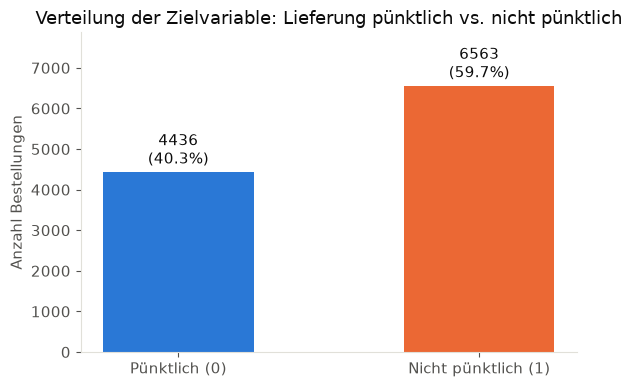

In [12]:
counts = df["Reached.on.Time_Y.N"].value_counts().sort_index()
labels = ["Pünktlich (0)", "Nicht pünktlich (1)"]
colors = [COLOR_BLUE, COLOR_ORANGE]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom")

ax.set_ylabel("Anzahl Bestellungen")
ax.set_title("Verteilung der Zielvariable: Lieferung pünktlich vs. nicht pünktlich")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Interpretation:** 6.563 Bestellungen (59,7 %) kamen nicht pünktlich an, 4.436 (40,3 %) pünktlich. Die Klassen sind also leicht unausgeglichen, aber nicht extrem (kein 95/5-Verhältnis). Für die spätere Modellierung heisst das: Eine Baseline, die immer "nicht pünktlich" vorhersagt, würde bereits ~59,7 % Accuracy erreichen — die Modellgüte muss also an dieser Baseline gemessen werden, und Metriken wie Precision/Recall/F1 sind aussagekräftiger als reine Accuracy.

### Visualisierung 2: Korrelationen zwischen den numerischen Merkmalen

Als Nächstes wird untersucht, wie die numerischen Merkmale untereinander und mit der Zielvariable zusammenhängen. Das hilft, potenziell relevante Prädiktoren für die spätere Modellierung zu identifizieren.

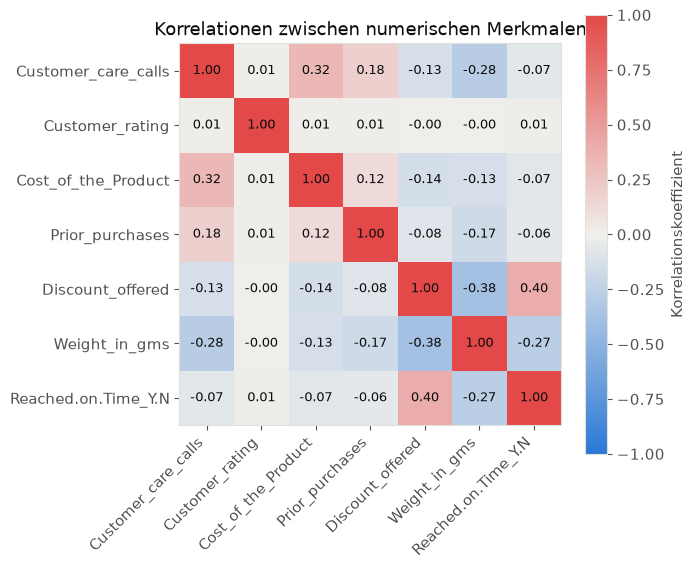

In [13]:
num_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]
corr = df[num_cols].corr()

diverging_cmap = LinearSegmentedColormap.from_list(
    "blue_red", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color=INK_COLOR, fontsize=9)

fig.colorbar(im, ax=ax, label="Korrelationskoeffizient")
ax.set_title("Korrelationen zwischen numerischen Merkmalen")
plt.tight_layout()
plt.show()

**Interpretation:** Die stärkste Korrelation mit der Zielvariable zeigt `Discount_offered` (+0,40) — je höher der Rabatt, desto wahrscheinlicher eine verspätete Lieferung. `Weight_in_gms` korreliert negativ (-0,27), d. h. schwerere Pakete kommen tendenziell eher pünktlich an. Alle übrigen Merkmale (`Customer_care_calls`, `Cost_of_the_Product`, `Prior_purchases`) hängen nur schwach (~-0,07) und `Customer_rating` praktisch gar nicht (0,01) mit der Pünktlichkeit zusammen. Bemerkenswert ist ausserdem die moderate Korrelation zwischen `Cost_of_the_Product` und `Customer_care_calls` (0,32): teurere Produkte lösen mehr Kundenservice-Anrufe aus, vermutlich weil Kund:innen bei hochpreisigen Bestellungen genauer nachfragen. Für die Modellierung deutet das darauf hin, dass `Discount_offered` und `Weight_in_gms` die informativsten numerischen Prädiktoren für Verspätungen sind.

### Visualisierung 3: Rabatt nach Lieferstatus

Da `Discount_offered` in der Korrelationsmatrix mit Abstand am stärksten mit der Zielvariable zusammenhängt, wird dieser Zusammenhang hier gezielt vertieft und visualisiert.

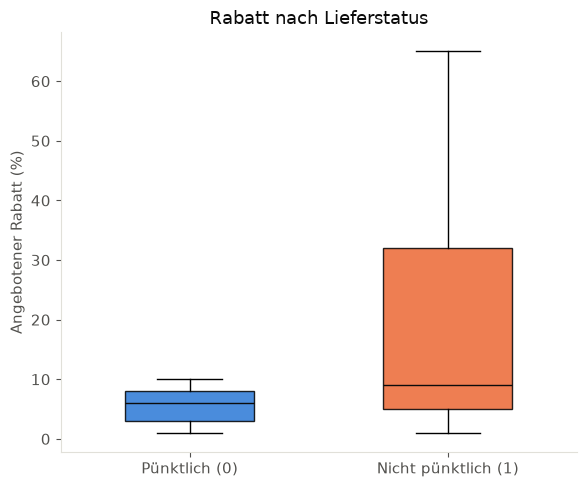

In [14]:
data_by_target = [df.loc[df["Reached.on.Time_Y.N"] == 0, "Discount_offered"],
                  df.loc[df["Reached.on.Time_Y.N"] == 1, "Discount_offered"]]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(data_by_target, tick_labels=["Pünktlich (0)", "Nicht pünktlich (1)"],
                 patch_artist=True, widths=0.5, medianprops=dict(color=INK_COLOR))

for patch, color in zip(bp["boxes"], [COLOR_BLUE, COLOR_ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel("Angebotener Rabatt (%)")
ax.set_title("Rabatt nach Lieferstatus")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretation:** Bestellungen mit pünktlicher Lieferung haben einen durchschnittlichen Rabatt von nur 5,55 %, während verspätete Lieferungen im Schnitt 18,66 % Rabatt aufweisen — mehr als das Dreifache. Der Boxplot zeigt zusätzlich, dass bei "nicht pünktlich" die gesamte Verteilung (Median, Quartile, Streuung) deutlich höher liegt und weiter nach oben reicht. Dieser Zusammenhang ist damit der stärkste Einzelprädiktor im Datensatz. Wie bereits in Teil 1 unter "Einschränkungen" angemerkt, ist dabei aber Vorsicht geboten: Der Zusammenhang ist eine Korrelation, keine bewiesene Kausalität — denkbar wäre z. B., dass hohe Rabatte im Rahmen von Sales-Aktionen mit höherem Bestellvolumen und dadurch überlasteter Logistik einhergehen, statt dass der Rabatt selbst die Verspätung verursacht.

### Zusammenfassung der Erkenntnisse aus der EDA

- Die Zielvariable ist leicht unausgeglichen (59,7 % verspätet vs. 40,3 % pünktlich) — bei der Modellbewertung sollten daher nicht nur die Accuracy, sondern auch Precision, Recall und F1-Score betrachtet werden.
- `Discount_offered` ist der mit Abstand stärkste Einzelprädiktor für Verspätungen (Korrelation +0,40): Höhere Rabatte gehen mit deutlich höherer Verspätungswahrscheinlichkeit einher (Ø 18,66 % vs. 5,55 %).
- `Weight_in_gms` hängt schwach negativ mit Verspätungen zusammen (-0,27): schwerere Sendungen kommen tendenziell eher pünktlich an, was z. B. auf bevorzugte Behandlung schwerer/wertvoller Fracht hindeuten könnte.
- Merkmale wie `Customer_rating`, `Customer_care_calls`, `Cost_of_the_Product` und `Prior_purchases` zeigen kaum bis keinen linearen Zusammenhang mit der Pünktlichkeit und sind daher als alleinige Prädiktoren wenig aussagekräftig.
- Insgesamt liefert die EDA einen klaren Hinweis darauf, dass `Discount_offered` und `Weight_in_gms` für die spätere Modellierung besonders relevante Merkmale sind, während gleichzeitig daran erinnert werden muss, dass Korrelation keine Kausalität beweist.

## 2.4 Feature Engineering

### Kategoriale Variablen kodieren

Die meisten ML-Modelle benötigen numerische Eingaben. Die vier kategorialen Spalten werden daher wie folgt kodiert:

- **`Product_importance`** (LOW/MEDIUM/HIGH) → **Ordinal-Encoding** (0/1/2), da hier eine echte Rangfolge existiert
- **`Warehouse_block`, `Mode_of_Shipment`, `Gender`** → **One-Hot-Encoding**, da diese Kategorien keine natürliche Reihenfolge haben (nominal). `drop_first=True` verhindert dabei die "Dummy Variable Trap" (perfekte Multikollinearität zwischen den erzeugten Spalten).

In [15]:
# Ordinal-Encoding für Product_importance (natürliche Rangfolge: LOW < MEDIUM < HIGH)
importance_map = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
df["Product_importance"] = df["Product_importance"].map(importance_map)

# One-Hot-Encoding für nominale Variablen ohne natürliche Rangfolge
df = pd.get_dummies(df, columns=["Warehouse_block", "Mode_of_Shipment", "Gender"], drop_first=True)

df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,z_score,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_ROAD,Mode_of_Shipment_SHIP,Gender_M
0,1,4,2,177,3,0,44,1233,1,1.889897,False,False,True,False,False,False,False
1,2,4,5,216,2,0,59,3088,1,2.815508,False,False,False,True,False,False,True
2,3,2,2,183,4,0,48,3374,1,2.136727,False,False,False,False,False,False,True
3,4,3,3,176,4,1,10,1177,1,-0.208152,True,False,False,False,False,False,True
4,5,2,2,184,3,1,46,2484,1,2.013312,False,True,False,False,False,False,False


### Abgeleitetes Feature: Discount_ratio

`Discount_offered` wurde bisher nur absolut betrachtet. Da Produkte sehr unterschiedlich teuer sind, sagt ein Rabatt von z. B. 20 bei einem 50-Dollar-Produkt etwas anderes aus als bei einem 300-Dollar-Produkt. Deshalb wird der Rabatt relativ zum Produktpreis berechnet:

`Discount_ratio = Discount_offered / Cost_of_the_Product`

Da `Discount_offered` bereits die stärkste Korrelation mit der Zielvariable hatte (+0,40), wird geprüft, ob die relative Betrachtung diesen Zusammenhang noch schärfer erfasst.

In [16]:
df["Discount_ratio"] = df["Discount_offered"] / df["Cost_of_the_Product"]

print(df[["Discount_offered", "Cost_of_the_Product", "Discount_ratio"]].head())
print()
print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Discount_offered", "Discount_ratio", "Reached.on.Time_Y.N"]].corr()["Reached.on.Time_Y.N"])

   Discount_offered  Cost_of_the_Product  Discount_ratio
0                44                  177        0.248588
1                59                  216        0.273148
2                48                  183        0.262295
3                10                  176        0.056818
4                46                  184        0.250000

Korrelation mit Reached.on.Time_Y.N:
Discount_offered       0.397108
Discount_ratio         0.380484
Reached.on.Time_Y.N    1.000000
Name: Reached.on.Time_Y.N, dtype: float64


**Interpretation:** Entgegen der Erwartung ist die Korrelation von `Discount_ratio` mit der Zielvariable (0,380) minimal **schwächer** als die von `Discount_offered` (0,397). Der absolute Rabatt ist hier also der leicht informativere Prädiktor. Eine mögliche Erklärung: `Cost_of_the_Product` selbst korreliert kaum mit der Pünktlichkeit (-0,07), sodass die Division durch den Preis vor allem zusätzliches Rauschen einbringt, ohne den eigentlichen Effekt zu verstärken. Trotzdem wird `Discount_ratio` als zusätzliches Feature im Datensatz behalten — bei nichtlinearen Modellen (z. B. Entscheidungsbäumen) kann ein relatives Mass auch dann nützlich sein, wenn die lineare Korrelation nicht steigt.

## 2.5 Train/Test-Split

**Begründung des Verhältnisses (80/20):**

Mit 10.999 Datensätzen ist der Datensatz gross genug, um sich an der gängigen Faustregel zu orientieren: 80 % Training / 20 % Test.
- 20 % Testdaten entsprechen ~2.200 Samples — genug, um die Modellgüte stabil und zuverlässig zu schätzen (kein zu kleines, verrauschtes Test-Set).
- 80 % Trainingsdaten (~8.799 Samples) reichen aus, damit das Modell genügend Beispiele zum Lernen hat, gerade auch für die unterrepräsentiertere Klasse (Pünktlich, 40,3 %).
- Ein extremeres Verhältnis (z. B. 90/10) würde das Testset unnötig verkleinern, ein kleineres (z. B. 70/30) würde dem Modell unnötig Trainingsdaten entziehen, ohne dass es hier — bei einem mittelgrossen, nicht besonders komplexen tabellarischen Datensatz — nötig wäre.

**Stratifizierung:**

In Abschnitt 2.3 wurde festgestellt, dass die Zielvariable leicht unausgeglichen ist (59,7 % nicht pünktlich vs. 40,3 % pünktlich). Ohne Stratifizierung könnte ein zufälliger Split dieses Verhältnis in Trainings- und Testdaten leicht verschieben, was die Modellbewertung verzerren würde. Deshalb wird `train_test_split` mit `stratify=y` durchgeführt: Damit wird sichergestellt, dass die Klassenverteilung in Trainings- und Testdaten (annähernd) identisch zur Gesamtverteilung bleibt — eine wichtige Voraussetzung für eine verlässliche und vergleichbare Modellbewertung.

Unrelevante Spalten werden entfernt

In [17]:
X=df.drop(columns=["ID", "Reached.on.Time_Y.N", "z_score"])
y=df["Reached.on.Time_Y.N"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trainingsdaten: {X_train.shape[0]} Samples, Testdaten: {X_test.shape[0]} Samples")
print()
print("Klassenverteilung gesamt:")
print(y.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Training:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Test:")
print(y_test.value_counts(normalize=True).round(3))

Trainingsdaten: 8799 Samples, Testdaten: 2200 Samples

Klassenverteilung gesamt:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Training:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Test:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64
